In [1]:
import xradar as xd
import fsspec
import matplotlib.pyplot as plt
import wradlib as wrl
import xarray as xr
import numpy as np

In [2]:
fs = fsspec.filesystem("s3", anon=True)
year = 2024
car_files =  ['s3://' + f for f in 
              sorted(fs.glob(f"s3-radaresideam/l2_data/{year}/08/09/Carimagua/CAR*"))
             ]
gua_files = ['s3://' + f for f in 
             sorted(fs.glob(f"s3-radaresideam/l2_data/{year}/08/09/Guaviare/GUA*"))
            ]
tab_files =  ['s3://' + f for f in 
              sorted(fs.glob(f"s3-radaresideam/l2_data/{year}/08/09/Tablazo/TAB*"))
             ]


In [3]:
def download_s3file(s3_path: str)-> str:
    return fsspec.open_local(
            f"simplecache::s3://{s3_path}",
            s3={"anon": True},
            filecache={"cache_storage": "."},
        )

In [4]:
dt_car = xd.io.open_iris_datatree(
    download_s3file(car_files[7])
    ).xradar.georeference()
    
dt_gua = xd.io.open_iris_datatree(
    download_s3file(gua_files[3])
).xradar.georeference()


In [5]:
ctree = xr.DataTree.from_dict(
    {
    "CAR": dt_car, 
    "GUA": dt_gua
    }
)

In [6]:
tformat = "%Y-%m-%dT%H:%M:%S"

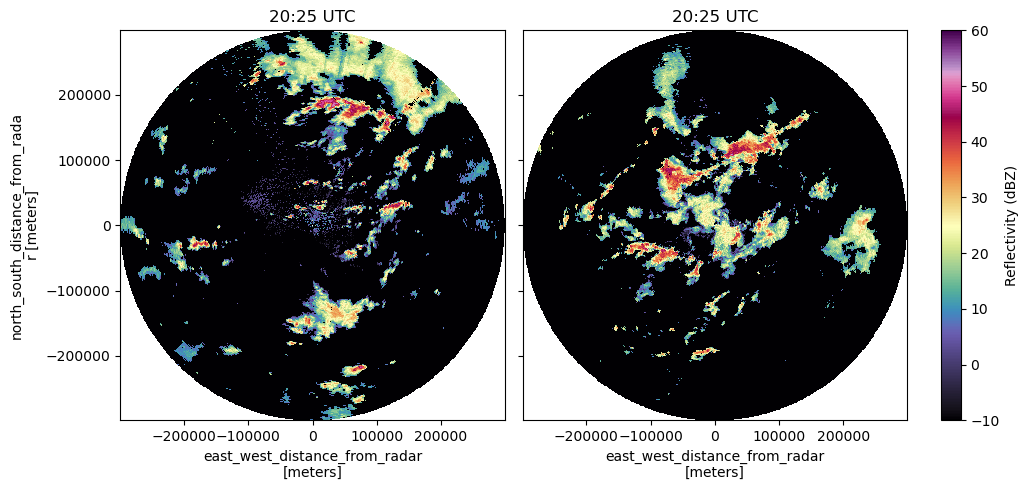

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# Common settings
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_car['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_title(dt_car['sweep_0'].time.min().dt.strftime(tformat).values)

# Plot GUA
p2 = dt_gua['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title(dt_gua['sweep_0'].time.min().dt.strftime(tformat).values)
axs[1].set_ylabel("")
plt.tight_layout()

# Add shared colorbar
cbar = fig.colorbar(p2, ax=axs, orientation="vertical", fraction=0.045, pad=0.04)
cbar.set_label("Reflectivity (dBZ)")

plt.show()


In [9]:
proj_utm = wrl.georef.epsg_to_osr(4326)

In [10]:
for radar in ctree.children:
    ctree[radar]["sweep_0"].ds = ctree[radar]["sweep_0"].ds.wrl.georef.georeference(crs=proj_utm)

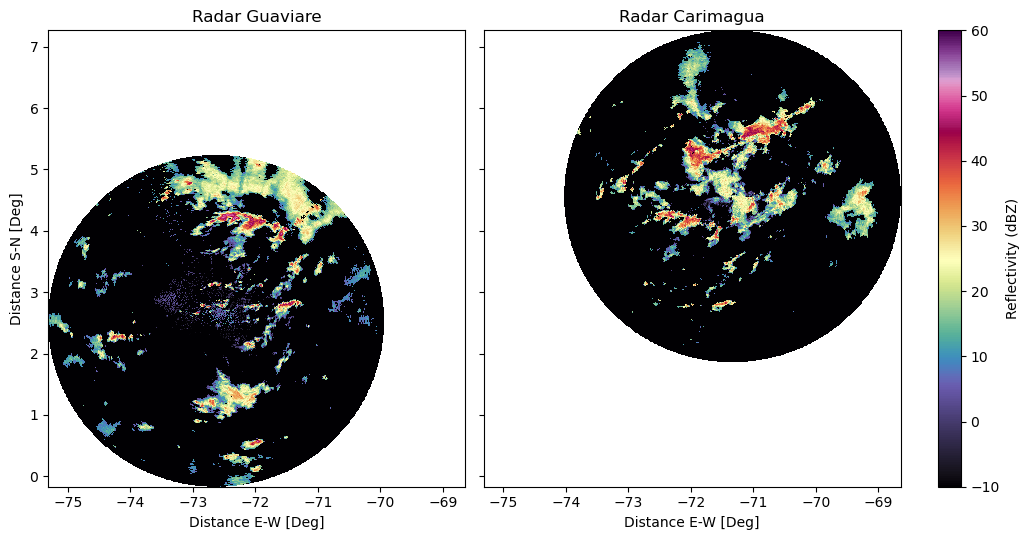

In [29]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    1, 2, figsize=(10, 5.5), sharex=True, sharey=True,
    gridspec_kw={'width_ratios': [1, 1]}  # keeps plots equal size
)

# Common settings
vmin, vmax = -10, 60
cmap = "ChaseSpectral"

# Plot 1
ax1 = axs[0]
p1 = ctree["GUA/sweep_0"].ds.DBZH.plot(
    x="x",
    y="y",
    ax=ax1,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False
)
ax1.set_title("Radar Guaviare")
ax1.set_xlabel("Distance E-W [Deg]")
ax1.set_ylabel("Distance S-N [Deg]")

# Plot 2
ax2 = axs[1]
p2 = ctree["CAR/sweep_0"].ds.DBZH.plot(
    x="x",
    y="y",
    ax=ax2,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False
)
ax2.set_title("Radar Carimagua")
ax2.set_ylabel("")
ax2.set_xlabel("Distance E-W [Deg]")

fig.tight_layout()

# Add vertical shared colorbar on the right
cbar = fig.colorbar(p2, ax=axs, orientation="vertical", fraction=0.045, pad=0.04)
cbar.set_label("Reflectivity (dBZ)")


In [12]:
%%time
for radar in ctree.children:
    print(radar)
    ctree[f"{radar}/sweep_0"].ds = ctree[f"{radar}/sweep_0"].ds.wrl.georef.georeference(crs=proj_utm)
    ctree[f"{radar}/sweep_0"].ds = ctree[f"{radar}/sweep_0"].ds.assign(QUAL=ctree[f"{radar}/sweep_0"].ds.range.wrl.qual.pulse_volume(250.0, 0.9).expand_dims(azimuth=ctree[f"{radar}/sweep_0"].ds.azimuth))
    ra, si = ctree[f"{radar}/sweep_0"].ds.DBZH.wrl.trafo.idecibel().wrl.zr.z_to_r_enhanced()
    ctree[f"{radar}/sweep_0"].ds = ctree[f"{radar}/sweep_0"].ds.assign(RAIN=ra)
ctree

CAR
GUA
CPU times: user 1.98 s, sys: 74 ms, total: 2.06 s
Wall time: 2.05 s


<xarray.DataTree>
Group: /
├── Group: /CAR
│   │   Dimensions:              (sweep: 1)
│   │   Dimensions without coordinates: sweep
│   │   Data variables:
│   │       volume_number        int64 8B 0
│   │       platform_type        <U5 20B 'fixed'
│   │       instrument_type      <U5 20B 'radar'
│   │       time_coverage_start  <U20 80B '2024-08-09T20:25:05Z'
│   │       time_coverage_end    <U20 80B '2024-08-09T20:26:21Z'
│   │       longitude            float64 8B -71.33
│   │       altitude             float64 8B 206.0
│   │       latitude             float64 8B 4.564
│   │       sweep_group_name     (sweep) int64 8B 0
│   │       sweep_fixed_angle    (sweep) float64 8B 0.5
│   │   Attributes:
│   │       Conventions:      None
│   │       instrument_name:  carimagua-radar
│   │       version:          None
│   │       title:            None
│   │       institution:      None
│   │       references:       None
│   │       source:           Sigmet
│   │       history:          None
│   │       comment:          Primera tarea del modo precipitacion / 0.5
│   │       scan_name:        SURVP       
│   ├── Group: /CAR/sweep_0
│   │       Dimensions:            (azimuth: 720, range: 994)
│   │       Coordinates: (12/14)
│   │           elevation          (azimuth) float64 6kB 0.5054 0.5054 ... 0.5054 0.5054
│   │           time               (azimuth) datetime64[ns] 6kB 2024-08-09T20:26:01.32400...
│   │         * range              (range) float32 4kB 1e+03 1.3e+03 ... 2.986e+05 2.989e+05
│   │           longitude          float64 8B -71.33
│   │           latitude           float64 8B 4.564
│   │           altitude           float64 8B 206.0
│   │           ...                 ...
│   │           x                  (azimuth, range) float64 6MB -71.33 -71.33 ... -71.35
│   │           y                  (azimuth, range) float64 6MB 4.573 4.575 ... 7.262 7.264
│   │           z                  (azimuth, range) float64 6MB 214.9 217.6 ... 8.091e+03
│   │           gr                 (azimuth, range) float64 6MB 0.009043 0.01176 ... 2.701
│   │           rays               (azimuth, range) float32 3MB 0.03571 0.03571 ... 359.6
│   │           bins               (azimuth, range) float32 3MB 1e+03 1.3e+03 ... 2.989e+05
│   │       Data variables: (12/19)
│   │           DBTH               (azimuth, range) float32 3MB ...
│   │           DBZH               (azimuth, range) float64 6MB 4.5 8.5 ... -32.0 -32.0
│   │           VRADH              (azimuth, range) float32 3MB ...
│   │           WRADH              (azimuth, range) float32 3MB ...
│   │           ZDR                (azimuth, range) float32 3MB ...
│   │           KDP                (azimuth, range) float32 3MB ...
│   │           ...                 ...
│   │           sweep_number       int64 8B ...
│   │           prt_mode           <U7 28B ...
│   │           follow_mode        <U7 28B ...
│   │           sweep_fixed_angle  float64 8B ...
│   │           QUAL               (azimuth, range) float64 6MB 4.845e+04 ... 4.329e+09
│   │           RAIN               (azimuth, range) float64 6MB 0.03404 ... 0.0001646
│   ├── Group: /CAR/radar_parameters
│   │       Dimensions:    ()
│   │       Coordinates:
│   │           longitude  float64 8B ...
│   │           latitude   float64 8B ...
│   │           altitude   float64 8B ...
│   ├── Group: /CAR/georeferencing_correction
│   │       Dimensions:    ()
│   │       Coordinates:
│   │           longitude  float64 8B ...
│   │           latitude   float64 8B ...
│   │           altitude   float64 8B ...
│   └── Group: /CAR/radar_calibration
└── Group: /GUA
    │   Dimensions:              (sweep: 1)
    │   Dimensions without coordinates: sweep
    │   Data variables:
    │       volume_number        int64 8B 0
    │       platform_type        <U5 20B 'fixed'
    │       instrument_type      <U5 20B 'radar'
    │       time_coverage_start  <U20 80B '2024-08-09T20:25:17Z'
    │       time_coverage_end    <U20 80B '2024-08-09T

In [13]:
def bbox(*args):
    """Get bounding box from a set of radar bin coordinates"""
    xy = np.array(
        [
            [
                arg.x.min().values,
                arg.x.max().values,
                arg.y.min().values,
                arg.y.max().values,
            ]
            for arg in args
        ]
    )
    xmin = xy[..., 0].min()
    xmax = xy[..., 1].max()
    ymin = xy[..., 2].min()
    ymax = xy[..., 3].max()

    return xmin, xmax, ymin, ymax

In [14]:
xmin, xmax, ymin, ymax = bbox(*[ctree[f"{radar}/sweep_0"].ds for radar in ctree.children])
x = np.linspace(xmin, xmax + 1000.0, 1000)
y = np.linspace(ymin, ymax + 1000.0, 1000)
cart = xr.Dataset(coords={"x": (["x"], x), "y": (["y"], y)})
display(cart)

<xarray.Dataset> Size: 16kB
Dimensions:  (x: 1000, y: 1000)
Coordinates:
  * x        (x) float64 8kB -75.31 -74.31 -73.3 -72.29 ... 929.3 930.4 931.4
  * y        (y) float64 8kB -0.1673 0.8411 1.85 ... 1.006e+03 1.007e+03
Data variables:
    *empty*

In [15]:
ctree["CAR/sweep_0"].ds

<xarray.DatasetView> Size: 76MB
Dimensions:            (azimuth: 720, range: 994)
Coordinates: (12/14)
    elevation          (azimuth) float64 6kB 0.5054 0.5054 ... 0.5054 0.5054
    time               (azimuth) datetime64[ns] 6kB 2024-08-09T20:26:01.32400...
  * range              (range) float32 4kB 1e+03 1.3e+03 ... 2.986e+05 2.989e+05
    longitude          float64 8B -71.33
    latitude           float64 8B 4.564
    altitude           float64 8B 206.0
    ...                 ...
    x                  (azimuth, range) float64 6MB -71.33 -71.33 ... -71.35
    y                  (azimuth, range) float64 6MB 4.573 4.575 ... 7.262 7.264
    z                  (azimuth, range) float64 6MB 214.9 217.6 ... 8.091e+03
    gr                 (azimuth, range) float64 6MB 0.009043 0.01176 ... 2.701
    rays               (azimuth, range) float32 3MB 0.03571 0.03571 ... 359.6
    bins               (azimuth, range) float32 3MB 1e+03 1.3e+03 ... 2.989e+05
Data variables: (12/19)
    DBTH               (azimuth, range) float32 3MB ...
    DBZH               (azimuth, range) float64 6MB 4.5 8.5 ... -32.0 -32.0
    VRADH              (azimuth, range) float32 3MB ...
    WRADH              (azimuth, range) float32 3MB ...
    ZDR                (azimuth, range) float32 3MB ...
    KDP                (azimuth, range) float32 3MB ...
    ...                 ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    QUAL               (azimuth, range) float64 6MB 4.845e+04 ... 4.329e+09
    RAIN               (azimuth, range) float64 6MB 0.03404 ... 0.0001646

In [16]:
%%time
gtree = xr.DataTree()
for radar in ctree.children:
    print(radar)
    gridded = ctree[f"{radar}/sweep_0"].ds.wrl.comp.togrid(
        cart,
        radius=180000.0,
        center=(ctree[f"{radar}/sweep_0"].ds.y.mean(), ctree[f"{radar}/sweep_0"].ds.x.mean()), # location of radar in lat/lon
        interpol=wrl.ipol.Nearest, # scipy KDTree based         
    )
    gtree[f"{radar}/sweep_0"] = gridded


CAR


TypeError: togrid() missing 1 required positional argument: 'data'